In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time
import torch.nn.functional as F
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import sampler
import numpy as np
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import ImageGrid
from torchvision.utils import save_image, make_grid

In [2]:
# Hyperparameters
RANDOM_SEED = 49      ## Random number seed
LEARNING_RATE = 0.0002  ## learning rate
BATCH_SIZE = 256      ##Batch size for stochastic learning
NUM_EPOCHS = 50       ##Number of epochs
NUM_CLASSES = 10      ##number of classes in image
device = torch.device("cuda:0")

In [3]:
## Data loader and generator
def get_dataloaders_mnist(batch_size, num_workers=0,
                          train_transforms=None, test_transforms=None):
  """
    Function: To create dataloader and datagenerator from dataset
    Input:
      batch_size: Size of individual batch of data
      num_workers: number of parallel workers
      train_transforms: Transformations applied to training dataset
      test_transforms: Transformations applied to testing dataset

  """
  ## Add transform to training input
  if train_transforms is None:
      train_transforms = transforms.Compose([
          transforms.ToTensor()
      ])
  ## Add transform to test input
  if test_transforms is None:
      test_transforms = transforms.Compose([
          transforms.ToTensor()
      ])
  ## Import the training dataset
  train_dataset = datasets.MNIST(root='data',
                                train=True,
            transform=train_transforms,download=True)
  ## Import the validation dataset
  valid_dataset = datasets.MNIST(root='data',
                                  train=True,
                                  transform=test_transforms)
  ## Import the test dataset
  test_dataset = datasets.MNIST(root='data',
                                train=False,
                                transform=test_transforms)
  ## Convert the training dataset into iterative dataloader
  train_loader = DataLoader(dataset=train_dataset,
                            batch_size=batch_size,
                            num_workers=num_workers,
                            shuffle=True)
  ## Convert the validation dataset into iterative dataloader
  valid_loader = DataLoader(dataset=valid_dataset,
                            batch_size=batch_size,
                            num_workers=num_workers,
                            shuffle=False)
  ## Convert the test dataset into iterative dataloader
  test_loader = DataLoader(dataset=test_dataset,
                            batch_size=batch_size,
                            num_workers=num_workers,
                            shuffle=False)
  return train_loader, valid_loader, test_loader
train_loader, valid_loader, test_loader = get_dataloaders_mnist(batch_size=BATCH_SIZE,
    num_workers=2)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:02<00:00, 4405583.44it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 130672.85it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:03<00:00, 461335.98it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 4723661.98it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



torch.Size([256, 1, 28, 28])


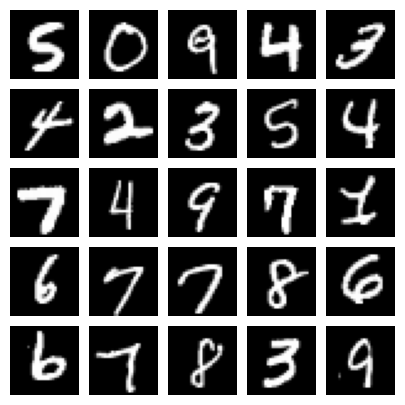

In [7]:
# get 25 sample training images for visualization
## Get the next iteration loader
dataiter = iter(train_loader)
image, labels = next(dataiter)
print(image.size())
num_samples = 25
sample_images = [image[i,0] for i in range(num_samples)]

fig = plt.figure(figsize=(5, 5))
grid = ImageGrid(fig, 111, nrows_ncols=(5, 5), axes_pad=0.1)

for ax, im in zip(grid, sample_images):
    ax.imshow(im, cmap='gray')
    ax.axis('off')

plt.show()

In [11]:
class VAE(nn.Module):
    """
    Variational Autoencoder
    Input = 28x28
    Hidden = 400
    Latent_Dim = 200
    """
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200, device=device):
        super(VAE, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            ## Linear Layer 1
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            ## Linear Layer 2
            nn.Linear(hidden_dim, latent_dim),
            nn.LeakyReLU(0.2)
            )

        # latent mean and variance
        self.mean_layer = nn.Linear(latent_dim, 2)
        self.logvar_layer = nn.Linear(latent_dim, 2)

        # decoder
        self.decoder = nn.Sequential(
            ## Linear to latent dimension
            nn.Linear(2, latent_dim),
            nn.LeakyReLU(0.2),
            ## Linear latent to hidden
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            ## Linear hidden to input
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
            )

    ## Encoder
    def encode(self, x):
        x = self.encoder(x)
        ## Calculate mean and variance of the latent distribution
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar


    ## Reparamatrize for decoder
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)
        z = mean + var*epsilon
        return z

    ## Decoder
    def decode(self, x):
        return self.decoder(x)

    ## Forward pass
    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        x_hat = self.decode(z)
        return x_hat, mean, logvar

In [12]:
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [13]:
def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD

In [18]:
def train(model, optimizer, epochs, device):
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            #x_dim = x.view(BATCH_SIZE, -1).size(1)
            #x = x.view(BATCH_SIZE, x_dim).to(device)
            x = x.view(x.size(0), -1).to(device)
            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)

            overall_loss += loss.item()

            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*BATCH_SIZE))
    return overall_loss

train(model, optimizer, epochs=50, device=device)

	Epoch 1 	Average Loss:  176.27607730311206
	Epoch 2 	Average Loss:  171.6283576671894
	Epoch 3 	Average Loss:  168.91573032150922
	Epoch 4 	Average Loss:  166.29095392145663
	Epoch 5 	Average Loss:  163.56793168874887
	Epoch 6 	Average Loss:  161.29499774509006
	Epoch 7 	Average Loss:  159.3506674318232
	Epoch 8 	Average Loss:  157.81678154122116
	Epoch 9 	Average Loss:  156.5122596545097
	Epoch 10 	Average Loss:  155.43773272913745
	Epoch 11 	Average Loss:  154.43102347545135
	Epoch 12 	Average Loss:  153.55956142784183
	Epoch 13 	Average Loss:  152.76215607080704
	Epoch 14 	Average Loss:  152.06551882751987
	Epoch 15 	Average Loss:  151.4090534601456
	Epoch 16 	Average Loss:  150.8024796216916
	Epoch 17 	Average Loss:  150.22081578898633
	Epoch 18 	Average Loss:  149.71554607815213
	Epoch 19 	Average Loss:  149.2070513505202
	Epoch 20 	Average Loss:  148.75288984510632
	Epoch 21 	Average Loss:  148.22705658480652
	Epoch 22 	Average Loss:  147.8085880931626
	Epoch 23 	Average Loss:  

8406070.53125

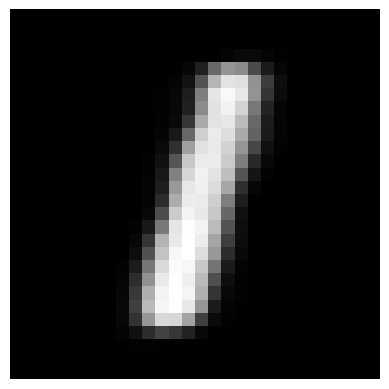

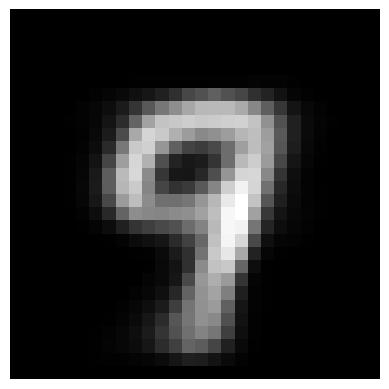

(None, None)

In [19]:
def generate_digit(mean, var):
    z_sample = torch.tensor([[mean, var]], dtype=torch.float).to(device)
    x_decoded = model.decode(z_sample)
    digit = x_decoded.detach().cpu().reshape(28, 28) # reshape vector to 2d array
    plt.imshow(digit, cmap='gray')
    plt.axis('off')
    plt.show()

generate_digit(0.0, 1.0), generate_digit(1.0, 0.0)

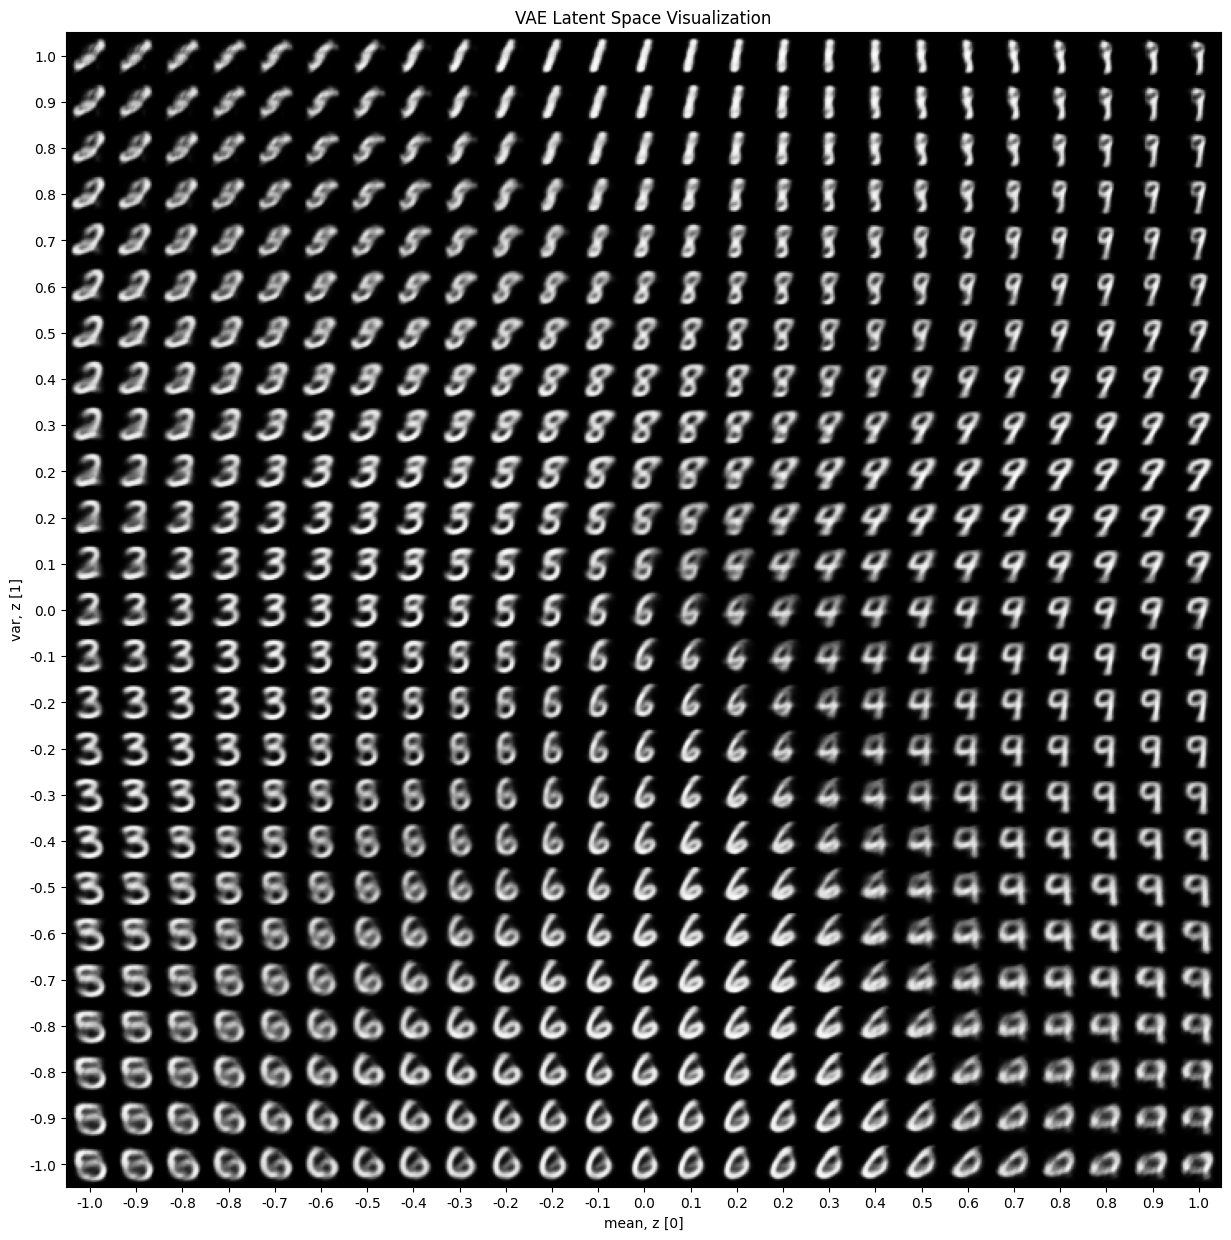

In [20]:
def plot_latent_space(model, scale=1.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(model)